# ROC-Based Predictive Analysis: 30-Day Price Movement Classification

### Logistic Regression Classifier

This notebook implements a supervised machine learning workflow to predict 30-day price movements using Logistic Regression.

**Data source:** `model_data.csv` — pre-processed by `DataPipeline.ipynb`

- Cleaning, feature engineering, multicollinearity reduction, and target creation are handled upstream
- This notebook focuses only on model training and evaluation

---

**Target: Price_Direction_30d**

- `1` → Positive 30-day forward ROC (price goes up)
- `0` → Non-positive 30-day forward ROC (price flat or down)

### **Initial Imports and Basic Settings**

We import all necessary libraries for:
- Data handling
- Visualization
- Model training
- Performance evaluation

In [176]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import loguniform
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve
)
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

### **Data Loading**

We load the **processed dataset** generated from the data pipeline.

This dataset already contains:
- Selected technical indicators
- Cleaned and aligned features
- Target variable for classification

In [177]:
# Load the data
df = pd.read_csv('../model_data.csv')

df.tail()

,Date,MACD_Signal,BB_Width,RSI_lag1,ATR_Pct,SMA20_Dist,Stoch_K,ROC_roll5_mean,Volume_Ratio,CCI,Price_Direction_30d
6474,2024-12-24,-1.316029,0.132917,53.420199,0.036962,0.022239,57.605026,-5.261791,0.521328,-2661.249878,0
6475,2024-12-26,-1.208039,0.133960,54.117403,0.035986,0.019007,67.450442,-3.698126,0.586880,-2585.840750,0
6476,2024-12-27,-1.106751,0.133217,53.661310,0.036849,-0.002864,68.248848,-2.044835,0.873814,-2688.993524,0
6477,2024-12-30,-1.004791,0.133130,49.168098,0.037344,0.000906,69.179531,-0.867510,0.853569,-2706.935786,0
6478,2024-12-31,-0.956520,0.134497,49.910595,0.037758,-0.020842,62.522172,-0.568523,0.795362,-2694.084442,1


### **Dataset Overview**

We inspect the dataset structure to verify:
- Number of rows and columns
- Feature availability
- Data types

In [178]:
#Printing info to check for data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6479 entries, 0 to 6478
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 6479 non-null   str    
 1   MACD_Signal          6479 non-null   float64
 2   BB_Width             6479 non-null   float64
 3   RSI_lag1             6479 non-null   float64
 4   ATR_Pct              6479 non-null   float64
 5   SMA20_Dist           6479 non-null   float64
 6   Stoch_K              6479 non-null   float64
 7   ROC_roll5_mean       6479 non-null   float64
 8   Volume_Ratio         6479 non-null   float64
 9   CCI                  6479 non-null   float64
 10  Price_Direction_30d  6479 non-null   int64  
dtypes: float64(9), int64(1), str(1)
memory usage: 556.9 KB


## Feature selection and target definition

We define the feature set and target variable used for model training.

These features are derived from technical indicators created during the data pipeline stage.

In [179]:
#These are the features selected after multi-collinearity check and MUTUAL INFORMATION analysis performed in Data_Pipeline.ipynb.
FEATURES = [
    "MACD_Signal",
    "BB_Width",
    "RSI_lag1",
    "ATR_Pct",
    "SMA20_Dist",
    "Stoch_K",
    "ROC_roll5_mean",
    "Volume_Ratio",
    "CCI"
]

TARGET = "Price_Direction_30d"

X = df[FEATURES]
y = df[TARGET]

print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))

Feature shape: (6479, 9)
Target distribution:
 Price_Direction_30d
1    0.616762
0    0.383238
Name: proportion, dtype: float64


## Train-test split

- We split the dataset into training, validation, and test sets.
The split is performed without shuffling to preserve temporal order and avoid data leakage.
- Verified the class balance for train and test set.

In [180]:
# Splitting data into train and test sets (15% test, without shuffling)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    shuffle=False
)

print(f"Train: {len(X_train)}  Test: {len(X_test)}")
# Checking class balance in train and test sets
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))

Train: 5507  Test: 972

Train class balance:
Price_Direction_30d
1    0.612
0    0.388
Name: proportion, dtype: float64

Test class balance:
Price_Direction_30d
1    0.646
0    0.354
Name: proportion, dtype: float64


### Feature scaling

Logistic Regression requires standardized features for stable training.

We apply StandardScaler to normalize feature distributions.

In [181]:
#Scaling features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train with RandomizedSearchCV

- We tune Logistic Regression hyperparameters using TimeSeriesSplit cross-validation to preserve the temporal order.
- Random split isn't preferred as it shuffles randomly and cause data leakage.
- We use class_weight = 'balanced' for reducing majority class bias

In [182]:
# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Base model
# 'Lbgfs' solver which is good for small datasets and supports L2 regularization.
log_reg = LogisticRegression(
    solver='lbfgs',         
    max_iter=2000,
    class_weight='balanced'
)

# Hyperparameter distribution 
param_dist = {
    "C": loguniform(1e-3, 10)
}
#C represents the inverse of regularization strength. Smaller values for stronger regularization.

# Randomized Search

#Scoring with 'roc_auc' is more suitable for imbalanced binary classification, because we want to distinguish between classes.
log_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit on training data
log_search.fit(X_train_scaled, y_train)

# Best model
best_model = log_search.best_estimator_

# Print best parameter
print("\nBest C:", log_search.best_params_["C"])

Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best C: 0.006290644294586149


## Performance across all splits

- We evaluate model performance on both training and test sets using standard classification metrics and ROC-AUC.

In [183]:
# Predictions
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)

# Probabilities for ROC-AUC
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]
y_train_proba = best_model.predict_proba(X_train_scaled)[:, 1]

# Metrics 
metrics = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'F1-Score': f1_score,
}

# Printing the table
print(f"\n{'Metric':<12} {'Train':>10} {'Test':>10}")


for name, fn in metrics.items():
    tr = fn(y_train, y_train_pred)
    te = fn(y_test, y_test_pred)
    print(f"{name:<12} {tr:>10.4f} {te:>10.4f}")

# ROC-AUC (both train and test)
roc_auc_train = roc_auc_score(y_train, y_train_proba)
roc_auc_test = roc_auc_score(y_test, y_test_proba)
print(f"\n{'ROC-AUC':<12} {roc_auc_train:>10.4f} {roc_auc_test:>10.4f}")
#Overfit gap Train accuracy - Test accuracy
print(f"\nOverfit gap(Train accuracy - Test accuracy) remains negligible {(accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred)):.4f}")



Metric            Train       Test
Accuracy         0.5497     0.5432
Precision        0.6498     0.6420
Recall           0.5719     0.6624
F1-Score         0.6083     0.6520

ROC-AUC          0.5684     0.4914

Overfit gap(Train accuracy - Test accuracy) remains negligible 0.0065


## Confusion Matrix and ROC Curve

- We visualize classification performance using confusion matrix and ROC curve.
- As a KPI, Precision is really important as a high number of false positives can backfire and result in trading losses
- ROC-AUC score is the most preferred evaluation metric for our model because it measures how well the model is able to 
  classify 0 and 1, across all possible thresholds. Since our data is imbalanced, accuracy can be misleading.

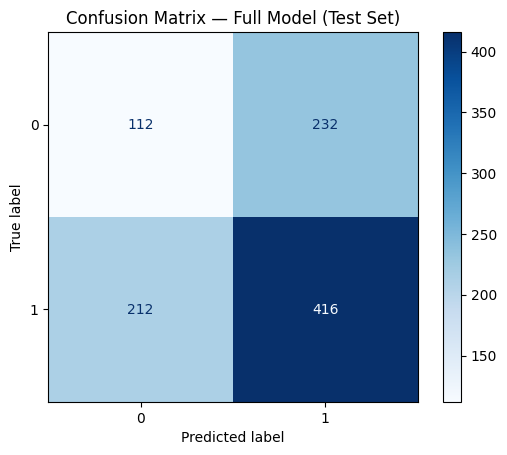

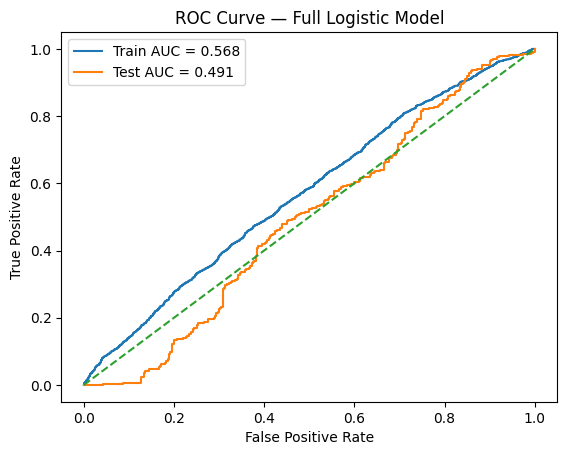

In [184]:
# Confusion Matrix (Test)

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix — Full Model (Test Set)")
plt.show()

# ROC Curve(Train and Test)

# Train ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
train_auc = roc_auc_score(y_train, y_train_proba)

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

plt.figure()

plt.plot(fpr_train, tpr_train, label=f"Train AUC = {train_auc:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")

# Random baseline green dotted line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Full Logistic Model")

plt.legend()
plt.show()

### Feature Importance (Logistic Regression Coefficients)

We interpret feature importance using model coefficients.
Higher absolute values indicate stronger influence on predictions.

          Feature  Coefficient  Abs_Coefficient
8             CCI    -0.155659         0.155659
3         ATR_Pct     0.117774         0.117774
2        RSI_lag1     0.110254         0.110254
0     MACD_Signal     0.105451         0.105451
4      SMA20_Dist     0.052926         0.052926
5         Stoch_K    -0.050482         0.050482
1        BB_Width    -0.049575         0.049575
6  ROC_roll5_mean     0.022460         0.022460
7    Volume_Ratio    -0.009600         0.009600


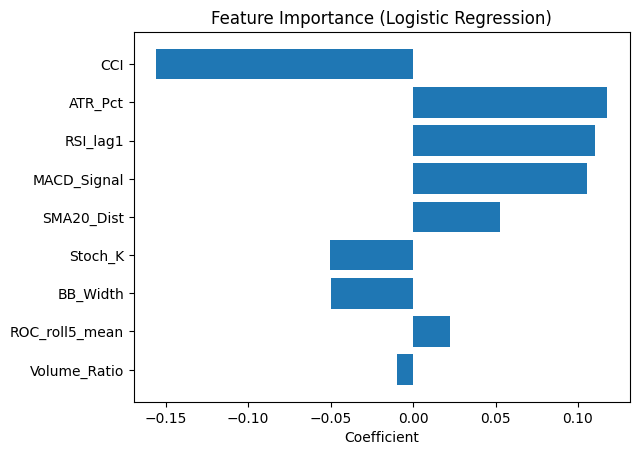

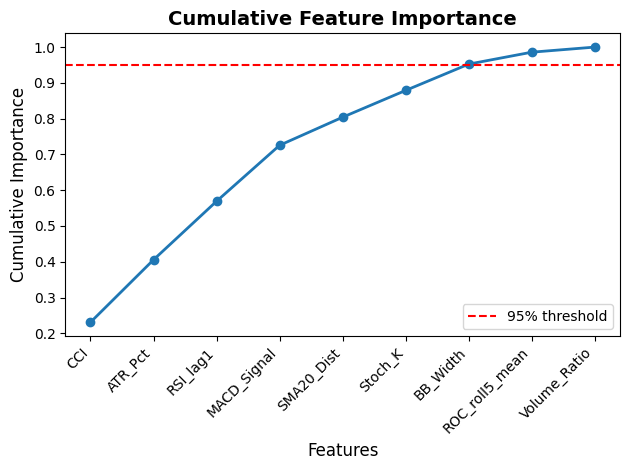

In [185]:
# Extract the coefficients off our best model
coef = best_model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': coef,
    'Abs_Coefficient': np.abs(coef)
}).sort_values(by='Abs_Coefficient', ascending=False)

# Display the feauture importances
print(feature_importance)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient")
plt.show()

fi = feature_importance.copy()

# Normalize importance
fi['Normalized'] = fi['Abs_Coefficient'] / fi['Abs_Coefficient'].sum()

# Cumulative sum
fi['Cumulative'] = fi['Normalized'].cumsum()


plt.figure()

# Line plot
plt.plot(fi['Feature'], fi['Cumulative'], marker='o', linewidth=2)

# Showing 95% threshold line
plt.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='95% threshold')

# Labels
plt.title("Cumulative Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Cumulative Importance", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### Dropping features which has low contribution to explaining the model

- We ranked features using logistic regression coefficients and select features contributing to 95% cumulative importance.
- Feature reduction is an important step to cut down the noise and reduce complexity.

In [186]:
#Feature Importance and Cumulative Selection (95%)

# 1) Extract coefficients from our best model
coef =best_model.coef_[0]

# 2) Creating feature importance dataframe (Absolute values)
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef,
    'Importance': np.abs(coef)
})

# 3) Sort them by importance
feat_imp_sorted = feat_imp.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# 4) Compute normalized cumulative importance
feat_imp_sorted['Cumulative'] = (
    feat_imp_sorted['Importance'].cumsum() /
    feat_imp_sorted['Importance'].sum()
)

# 5) Finding the cutoff in which (first index having cumulative >= 95%)
cutoff_idx = (feat_imp_sorted['Cumulative'] >= 0.95).idxmax()

# 6) Final selected features
FEATURES_FINAL =feat_imp_sorted.loc[:cutoff_idx,'Feature'].tolist()

# 7) Dropped features
DROPPED_FEATURES =feat_imp_sorted.loc[cutoff_idx + 1:,'Feature'].tolist()

# 8) Printing it out 
print("Selected Features (95% cumulative importance)")
print(feat_imp_sorted.loc[:cutoff_idx, ['Feature','Importance','Cumulative']].to_string(index=False))

print("\n Dropped Features (low contribution)")
print(feat_imp_sorted.loc[cutoff_idx + 1:,['Feature','Importance','Cumulative']].to_string(index=False))

print("\n Final feature list:")
print(FEATURES_FINAL)


Selected Features (95% cumulative importance)
    Feature  Importance  Cumulative
        CCI    0.155659    0.230886
    ATR_Pct    0.117774    0.405578
   RSI_lag1    0.110254    0.569116
MACD_Signal    0.105451    0.725530
 SMA20_Dist    0.052926    0.804034
    Stoch_K    0.050482    0.878913
   BB_Width    0.049575    0.952446

 Dropped Features (low contribution)
       Feature  Importance  Cumulative
ROC_roll5_mean     0.02246    0.985761
  Volume_Ratio     0.00960    1.000000

 Final feature list:
['CCI', 'ATR_Pct', 'RSI_lag1', 'MACD_Signal', 'SMA20_Dist', 'Stoch_K', 'BB_Width']


### Retraining on Reduced Feature Set

The model is now trained on these 7 selected features
['CCI', 'ATR_Pct', 'RSI_lag1', 'MACD_Signal', 'SMA20_Dist', 'Stoch_K', 'BB_Width']

In [187]:
# Logistic Regression (Reduced Features)

X2 = df[FEATURES_FINAL]
y2 = df[TARGET]

# Time-based split which is the same structure as full-feature model for fair comparison
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.15, shuffle=False
)

# Scaling features for reduced-features logistic regression
scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

# Verifying splits whether they match with the full-feature model
print(f"Train: {len(X2_train)}  |  Test: {len(X2_test)}")
print(f"Train date: {df.loc[X2_train.index[0], 'Date']} -> {df.loc[X2_train.index[-1], 'Date']}")
print(f"Test  date: {df.loc[X2_test.index[0],  'Date']} -> {df.loc[X2_test.index[-1],  'Date']}")
print(f"Same test indices as full model: {list(X2_test.index) == list(X_test.index)}")

# Time series CV
tscv = TimeSeriesSplit(n_splits=5)

#LR model with balanced class weights to handle class imbalance.
log_reg2 = LogisticRegression(
    solver='lbfgs',
    max_iter=5000,
    class_weight='balanced'
)

param_dist = {
    'C': loguniform(1e-4, 1e-1)
}

log_search2 = RandomizedSearchCV(
    estimator=log_reg2,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Training 
log_search2.fit(X2_train_sc, y2_train)
best_log2 = log_search2.best_estimator_

# Best params
print("\nBest parameters (reduced logistic model):")
for k, v in log_search2.best_params_.items():
    print(f"  {k:<10} {v}")

# Predictions
y2_train_pred  = best_log2.predict(X2_train_sc)
y2_test_pred   = best_log2.predict(X2_test_sc)
#Probabilities for ROC-AUC
y2_train_proba = best_log2.predict_proba(X2_train_sc)[:, 1]
y2_test_proba  = best_log2.predict_proba(X2_test_sc)[:, 1]

Train: 5507  |  Test: 972
Train date: 1999-04-05 -> 2021-02-19
Test  date: 2021-02-22 -> 2024-12-31
Same test indices as full model: True
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters (reduced logistic model):
  C          0.006358358856676255


### Comparing Reduced Feature Model and Full Feature Model
- We compare the models based on roc_auc score, precision, recall, accuracy and F1 score.

In [188]:
print("FULL MODEL vs REDUCED MODEL — TEST SET")
print(f"\n{'Metric':<12} {'Full (9 feat)':>15} {'Reduced ({} feat)'.format(len(FEATURES_FINAL)):>18}")

arrow = lambda diff: 'up' if diff > 0.001 else ('down' if diff < -0.001 else 'unchanged')

for name, fn in [
    ('Accuracy', accuracy_score),
    ('Precision', precision_score),
    ('Recall', recall_score),
    ('F1-Score', f1_score)
]:
    full = fn(y_test, y_test_pred)
    red  = fn(y2_test, y2_test_pred)
    diff = red - full
    print(f"{name:<12} {full:>15.4f} {red:>18.4f}  {arrow(diff)} {abs(diff):.4f}")

# ROC-AUC
full_auc = roc_auc_score(y_test, y_test_proba)
red_auc  = roc_auc_score(y2_test, y2_test_proba)
diff_auc = red_auc - full_auc

print(f"{'ROC-AUC':<12} {full_auc:>15.4f} {red_auc:>18.4f}  {arrow(diff_auc)} {abs(diff_auc):.4f}")
print("The results show that reduced model with 7 features performs very closely to the full model with 9 features.")
print("This suggests that the 2 dropped features had minimal contribution to the model's predictive performance")

FULL MODEL vs REDUCED MODEL — TEST SET

Metric         Full (9 feat)   Reduced (7 feat)
Accuracy              0.5432             0.5453  up 0.0021
Precision             0.6420             0.6435  up 0.0015
Recall                0.6624             0.6640  up 0.0016
F1-Score              0.6520             0.6536  up 0.0016
ROC-AUC               0.4914             0.4914  unchanged 0.0000
The results show that reduced model with 7 features performs very closely to the full model with 9 features.
This suggests that the 2 dropped features had minimal contribution to the model's predictive performance


### Confusion Matrix and ROC Curve for reduced features model
- The model shows negligible changes with near random AUC

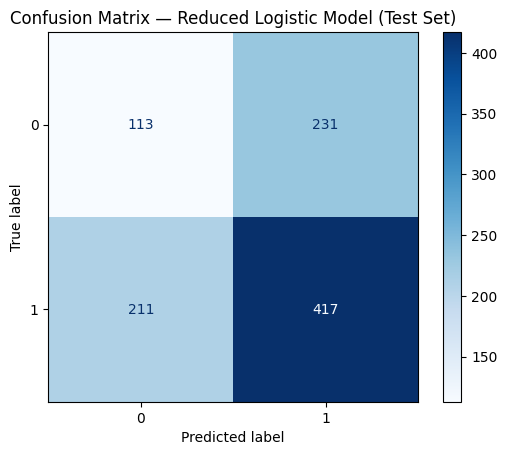

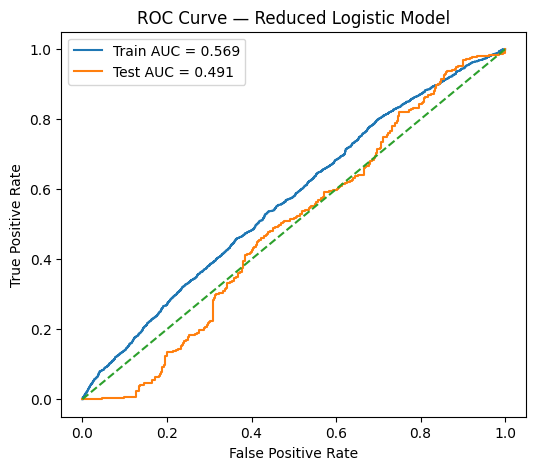

In [189]:
# Confusion Matrix for Reduced LR model (Test)
cm = confusion_matrix(y2_test, y2_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix — Reduced Logistic Model (Test Set)")
plt.grid(False)
plt.show()

# Train probabilities
y2_train_proba = best_log2.predict_proba(X2_train_sc)[:, 1]

# ROC values
fpr_train, tpr_train, _ = roc_curve(y2_train, y2_train_proba)
fpr_test,  tpr_test,  _ = roc_curve(y2_test,  y2_test_proba)

# AUC
auc_train = roc_auc_score(y2_train, y2_train_proba)
auc_test  = roc_auc_score(y2_test,  y2_test_proba)

# Plotting ROC curve for reduced logistic regression model
plt.figure(figsize=(6, 5))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.3f}")
plt.plot(fpr_test,  tpr_test,  label=f"Test AUC = {auc_test:.3f}")

# Baseline reference green dotted line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Reduced Logistic Model")
plt.legend()
plt.show()

### Diving Deeper into ROC Curve
- Logistic Regression's test AUC curve is coming below random (green dotted line) for FPR<=0.35. This means the model is unreliable for low FPR.
- For FPR above 0.35, the model is slightly better than random.
- For example, lets say FPR is 0.45 where the TPR is ~0.5, this implies that our model predicted 50% of true buy signals and made 45% losing buy signals which are essentially bad trades.
- From a trading perspective, the baseline model is unsuitable because false buy signals can cost a lot!

### Prediction Confidence Analysis — Reduced Logistic Model (Test Set)

- **Confidence vs Prediction Correctness:**  
  Correct predictions tend to have slightly higher confidence, but the spread is very similar across both correct and incorrect cases.  
  There are several wrong predictions with high confidence, which indicates the model can also be confidently incorrect.

- **Confidence Distribution (Correct vs Wrong):**  
  A large portion of predictions are clustered near very high confidence (close to 1.0).  
  However, both correct and incorrect predictions appear in this region, showing that high confidence is not exclusive to correct predictions.

- **Accuracy by Confidence:**  
  High confidence region (y_probability ≥ 0.7 or ≤ 0.3) covers majoriy of the samples with accuracy ≈ 0.587.  
  Low confidence region has fewer samples with lower accuracy ≈ 0.485.  

- **Key Takeaway:**  
  While higher confidence slightly improves accuracy, the difference is small.  
  Our model tends to assign high confidence even when predictions are wrong, so confidence alone is not a reliable indicator of correctness.


     SAMPLE PREDICTIONS     

   Actual  Predicted  Probability  Confidence  Correct
0       0          1     0.590730    0.181460    False
1       1          1     0.576937    0.153874     True
2       0          1     0.577049    0.154097    False
3       1          1     0.580078    0.160156     True
4       1          1     0.546909    0.093818     True


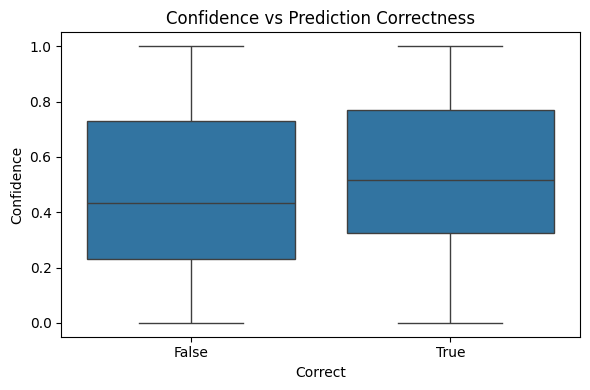

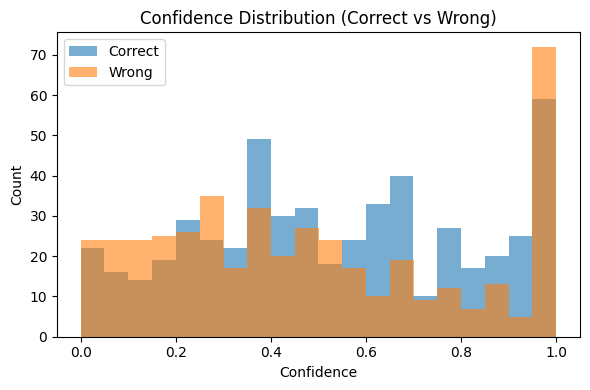


     ACCURACY BY CONFIDENCE     

High confidence (probability ≥ 0.7 or ≤ 0.3): 570 (58.6%)
Low confidence (0.3 < prob < 0.7): 402 (41.4%)

Accuracy —high confidence: 0.5877
Accuracy —low confidence: 0.4851


In [190]:
# Prediction Confidence Analysis (Test set - Reduced logistic regression model)

#Probabilities
y_prob = y2_test_proba
y_pred = y2_test_pred

# Confidence (defined as twice the distance from 0.5 probability, hence it ranges from 0 to 1)
confidence = np.abs(y_prob - 0.5)*2

# Results DataFrame 
results_df = pd.DataFrame({
    "Actual": y2_test.values,
    "Predicted": y_pred,
    "Probability": y_prob,
    "Confidence": confidence
})

results_df["Correct"]= results_df["Actual"] ==results_df["Predicted"]

print("\n     SAMPLE PREDICTIONS     \n")
print(results_df.head())


# 1) Confidence vs Prediction Correctness (Right or Wrong)
plt.figure(figsize=(6,4))
sns.boxplot(x="Correct", y="Confidence", data=results_df,showfliers=False)
plt.title("Confidence vs Prediction Correctness")
plt.tight_layout()
plt.show()


# 2) Distribution of Confidence for Correct vs Wrong Predictions
plt.figure(figsize=(6,4))

plt.hist(results_df[results_df["Correct"]]["Confidence"],
         bins=20, alpha=0.6, label="Correct")

plt.hist(results_df[~results_df["Correct"]]["Confidence"],
         bins=20, alpha=0.6, label="Wrong")

plt.xlabel("Confidence")
plt.ylabel("Count")
plt.title("Confidence Distribution (Correct vs Wrong)")
plt.legend()
plt.tight_layout()
plt.show()


# 3) ACCURACY BY PROBABILITY BANDS
#If probability is close to 0 or 1, we are more confident with our prediction. 
# If its close to 0.5, we are less confident.

high_conf =(results_df["Probability"] >= 0.7) | (results_df["Probability"] <= 0.3)
low_conf  =(results_df["Probability"] > 0.3) & (results_df["Probability"] < 0.7)

acc_high =results_df[high_conf]["Correct"].mean()
acc_low  =results_df[low_conf]["Correct"].mean()

print("\n     ACCURACY BY CONFIDENCE     \n")
print(f"High confidence (probability ≥ 0.7 or ≤ 0.3): {high_conf.sum()} "
      f"({high_conf.mean()*100:.1f}%)")
print(f"Low confidence (0.3 < prob < 0.7): {low_conf.sum()} "
      f"({low_conf.mean()*100:.1f}%)")

print(f"\nAccuracy —high confidence: {acc_high:.4f}")
print(f"Accuracy —low confidence: {acc_low:.4f}")

## Conclusion

- **Baseline Model Performance:**  
  Logistic Regression was used as a linear baseline. Despite hyperparameter tuning and feature reduction, ranking ability remains near random with ROC-AUC **0.491 (full-feature)** → **0.491 (reduced-feature)**. Train AUC (~0.569) vs test AUC (~0.491) indicates weak generalisation of signal.

- **Limitation of Linear Modeling:**  
  - The logistic Regression model fails to capture the non-linear, regime-dependant relationships between technical indicators and 30 day price direction. This indicates not our target variables are not linearly separable.
  - Features like RSI, CCI carry directional information only in context, high RSI in bullmarket is different than in a bear market. Such regime-dependant feature behavious is what our Logistic Regression model fails to understand.

- **Model Behavior (Class Bias):**  
  The model is biased toward predicting the positive class (upward movement)  
  Class 1 : **0.62**,
  Class 0 : **0.38**

- **Confidence Reliability:**  
  Predictions are heavily skewed toward high confidence:  
  - Accuracy: **0.587 (high confidence)** vs **0.485 (low confidence)**, High confidence accuracy is slightly higher but not good enough. 
  - Confidence distribution peaks near **1.0 for both correct and incorrect predictions** 
  .This indicates some degree of **overconfidence** with the model's predictions.

- **Overall Insights:**  
  - The baseline logistic regression model shows negligible improvements after feature reduction and model-tuning. 
    We get Near-random prediction power as expected.
  - The LR model has almost 2X False positives than True negatives, 2X True Positives than false Negatives. This suggests a positive bias. Without **class_weight='balanced'** the model would only be predicting positives. 
  - **ATR_pct, CCI, RSI_lag1** emerge as top 3 feature importances. All are volatility or oscillator based rather than trend following. This suggests that our model relies on extreme signals rather than directional signals.
  - We can conclude that to capture meaningful signals from technical indicators we would require **nonlinear models** capable of regime-aware feature interactions. This motivates us to pursue XGBoost and RandomForest which could potentially capture deeper directional signals .
  - From a business perspective, we deem the Logistic Regression model to be unsuitable for trading as it generates a lot of false buy signals. Higher prevalence of False positives compared to True positives can lead to trading losses.